# CNN cross-dataset eval (incl. thinkpad-2)

Evaluate the **fixed** training-domain CNN on all major feature datasets and compare accuracy.

- Model: `model-bn-c64-c128-c256-c256-d256.keras` (trained on clean training CQT only)
- Datasets: training (in-domain), vivo, thinkpad, **thinkpad-2**, flow, test-noisy
- Caches under `cnn-cross-eval-results/` for resume
- **Note:** training dataset is the train domain (expect very high accuracy); others are true OOD

## Config

In [1]:
from os import path
import pandas as pd
from IPython.display import display

FEATURES_DIR = path.normpath("../../features")
MODEL_PATH = path.normpath("../../models/model-bn-c64-c128-c256-c256-d256.keras")
TRAINING_FEATURES = path.join(FEATURES_DIR, "training.npz")

RESULTS_DIR = path.normpath("./cnn-cross-eval-results")
CACHE_DIR = path.join(RESULTS_DIR, "cache")
METRICS_DIR = path.join(RESULTS_DIR, "metrics")
SUMMARY_PATH = path.join(RESULTS_DIR, "summary.csv")
PROGRESS_PATH = path.join(RESULTS_DIR, "progress.csv")

# Primary datasets for cross-dataset comparison
EVAL_SETS = [
    {"name": "training", "domain": "training", "kind": "in_domain",
     "features": "training.npz"},
    {"name": "vivo", "domain": "vivo", "kind": "ood_device",
     "features": "vivo.npz"},
    {"name": "thinkpad", "domain": "thinkpad", "kind": "ood_device",
     "features": "thinkpad.npz"},
    {"name": "thinkpad_2", "domain": "thinkpad-2", "kind": "ood_keyboard",
     "features": "thinkpad-2.npz"},
    {"name": "flow", "domain": "flow", "kind": "ood_device",
     "features": "flow.npz"},
    {"name": "test_noisy", "domain": "test-noisy", "kind": "ood_noisy",
     "features": "test-noisy.npz"},
]

FORCE_REEVAL = False
BATCH_SIZE = 8
RANDOM_STATE = 42
TF_CPP_MIN_LOG_LEVEL = "3"

config_df = pd.DataFrame([
    {"key": "model_path", "value": MODEL_PATH},
    {"key": "results_dir", "value": RESULTS_DIR},
    {"key": "force_reeval", "value": FORCE_REEVAL},
    {"key": "batch_size", "value": BATCH_SIZE},
    {"key": "n_eval_sets", "value": len(EVAL_SETS)},
]).set_index("key")
display(config_df)
display(pd.DataFrame(EVAL_SETS))

,value
key,
model_path,../../models/model-bn-c64-c128-c256-c256-d256....
results_dir,cnn-cross-eval-results
force_reeval,False
batch_size,8
n_eval_sets,6


,name,domain,kind,features
0,training,training,in_domain,training.npz
1,vivo,vivo,ood_device,vivo.npz
2,thinkpad,thinkpad,ood_device,thinkpad.npz
3,thinkpad_2,thinkpad-2,ood_keyboard,thinkpad-2.npz
4,flow,flow,ood_device,flow.npz
5,test_noisy,test-noisy,ood_noisy,test-noisy.npz


## Setup

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = TF_CPP_MIN_LOG_LEVEL
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

import random
import numpy as np
import tensorflow as tf
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder
from os import makedirs, path

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError:
        pass

makedirs(CACHE_DIR, exist_ok=True)
makedirs(METRICS_DIR, exist_ok=True)

display(pd.DataFrame([{
    "tensorflow": tf.__version__,
    "gpus": str(gpus),
    "cache_dir": CACHE_DIR,
}]))

,tensorflow,gpus,cache_dir
0,2.15.0,"[PhysicalDevice(name='/physical_device:GPU:0',...",cnn-cross-eval-results/cache


## Helpers

In [3]:
def cache_path(name):
    return path.join(CACHE_DIR, f"{name}.npz")


def metrics_path(name):
    return path.join(METRICS_DIR, f"{name}.csv")


def load_class_names():
    with np.load(TRAINING_FEATURES, allow_pickle=True) as train:
        return np.sort(np.unique(np.asarray(train["labels"]).astype(str)))


def compute_metrics(y_true, y_pred, class_names, name, domain, kind):
    acc = accuracy_score(y_true, y_pred)
    p_m, r_m, f_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "name": name,
        "domain": domain,
        "kind": kind,
        "n_samples": int(len(y_true)),
        "n_classes": int(len(class_names)),
        "accuracy": float(acc),
        "macro_precision": float(p_m),
        "macro_recall": float(r_m),
        "macro_f1": float(f_m),
        "weighted_precision": float(p_w),
        "weighted_recall": float(r_w),
        "weighted_f1": float(f_w),
    }


def evaluate_one(spec, model, label_encoder, class_names):
    name = spec["name"]
    feat_path = path.join(FEATURES_DIR, spec["features"])
    cpath = cache_path(name)
    mpath = metrics_path(name)

    if path.isfile(cpath) and path.isfile(mpath) and not FORCE_REEVAL:
        cached = np.load(cpath, allow_pickle=True)
        with np.load(feat_path, allow_pickle=True) as src:
            n_src = int(np.asarray(src["labels"]).shape[0])
        n_cached = int(len(cached["y_true"]))
        if n_cached == n_src:
            metrics_df = pd.read_csv(mpath)
            return {
                "status": "cache_hit",
                "summary": metrics_df.iloc[0].to_dict(),
                "y_true": cached["y_true"],
                "y_pred": cached["y_pred"],
                "cache_path": cpath,
            }
        print(f"{name}: stale cache n={n_cached} vs dataset n={n_src}; re-evaluating")

    if not path.isfile(feat_path) and not path.islink(feat_path):
        raise FileNotFoundError(feat_path)

    with np.load(feat_path, allow_pickle=True) as data:
        features = data["features"]
        labels = np.asarray(data["labels"]).astype(str)

    unknown = sorted(set(labels) - set(class_names))
    if unknown:
        raise ValueError(f"{name}: labels not in training: {unknown[:5]}")

    y_true = label_encoder.transform(labels)
    x = features
    if x.ndim == 3:
        x = np.expand_dims(x, axis=-1)
    x = x.astype(np.float32, copy=False)

    proba = model.predict(x, batch_size=BATCH_SIZE, verbose=1)
    y_pred = np.argmax(proba, axis=1)
    summary = compute_metrics(
        y_true, y_pred, class_names, name, spec["domain"], spec["kind"]
    )

    np.savez_compressed(
        cpath,
        y_true=y_true.astype(np.int32),
        y_pred=y_pred.astype(np.int32),
        proba=proba.astype(np.float32),
        labels=labels.astype(str),
        class_names=class_names.astype(str),
        features_path=np.asarray(feat_path),
    )
    pd.DataFrame([summary]).to_csv(mpath, index=False)
    report = classification_report(
        y_true, y_pred,
        labels=np.arange(len(class_names)),
        target_names=list(class_names),
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(path.join(METRICS_DIR, f"{name}_report.csv"))

    return {
        "status": "computed",
        "summary": summary,
        "y_true": y_true,
        "y_pred": y_pred,
        "cache_path": cpath,
    }


display(pd.DataFrame([{"helpers": "ready"}]))

,helpers
0,ready


## Evaluate

In [4]:
assert path.isfile(MODEL_PATH), f"Missing model: {MODEL_PATH}"
assert path.isfile(TRAINING_FEATURES), f"Missing {TRAINING_FEATURES}"
for spec in EVAL_SETS:
    fp = path.join(FEATURES_DIR, spec["features"])
    assert path.isfile(fp) or path.islink(fp), f"Missing features: {fp}"

tf.keras.backend.clear_session()
model = tf.keras.models.load_model(MODEL_PATH)
class_names = load_class_names()
label_encoder = LabelEncoder()
label_encoder.fit(class_names)

display(pd.DataFrame([{
    "model": MODEL_PATH,
    "input_shape": model.input_shape,
    "output_shape": model.output_shape,
    "n_classes": len(class_names),
}]))

progress_rows = []
run_results = []
for spec in EVAL_SETS:
    result = evaluate_one(spec, model, label_encoder, class_names)
    run_results.append(result)
    row = dict(result["summary"])
    row["status"] = result["status"]
    progress_rows.append(row)
    pd.DataFrame(progress_rows).to_csv(PROGRESS_PATH, index=False)
    display(pd.DataFrame([row])[[
        "name", "domain", "kind", "status", "n_samples",
        "accuracy", "macro_f1", "weighted_f1",
    ]])

progress_df = pd.DataFrame(progress_rows)
display(progress_df.sort_values("accuracy", ascending=False).reset_index(drop=True))

,model,input_shape,output_shape,n_classes
0,../../models/model-bn-c64-c128-c256-c256-d256....,"(None, 216, 188, 1)","(None, 36)",36


,name,domain,kind,status,n_samples,accuracy,macro_f1,weighted_f1
0,training,training,in_domain,cache_hit,7200,0.999861,0.999861,0.999861


,name,domain,kind,status,n_samples,accuracy,macro_f1,weighted_f1
0,vivo,vivo,ood_device,cache_hit,1440,0.945833,0.937388,0.937388


,name,domain,kind,status,n_samples,accuracy,macro_f1,weighted_f1
0,thinkpad,thinkpad,ood_device,cache_hit,1440,0.994444,0.994428,0.994428


  1/180 [..............................] - ETA: 2:16

...

442/450 [============================>.] - ETA: 0s

447/450 [============================>.] - ETA: 0s

450/450 [==============================] - 5s 11ms/step


,name,domain,kind,status,n_samples,accuracy,macro_f1,weighted_f1
0,test_noisy,test-noisy,ood_noisy,computed,3600,0.821667,0.796196,0.796196


,name,domain,kind,n_samples,n_classes,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,status
0,training,training,in_domain,7200,36,0.999861,0.999862,0.999861,0.999861,0.999862,0.999861,0.999861,cache_hit
1,thinkpad,thinkpad,ood_device,1440,36,0.994444,0.994976,0.994444,0.994428,0.994976,0.994444,0.994428,cache_hit
2,vivo,vivo,ood_device,1440,36,0.945833,0.949536,0.945833,0.937388,0.949536,0.945833,0.937388,cache_hit
3,flow,flow,ood_device,1440,36,0.943750,0.964463,0.943750,0.935195,0.964463,0.943750,0.935195,computed
4,thinkpad_2,thinkpad-2,ood_keyboard,1440,36,0.885417,0.848812,0.885417,0.855961,0.848812,0.885417,0.855961,computed
5,test_noisy,test-noisy,ood_noisy,3600,36,0.821667,0.845275,0.821667,0.796196,0.845275,0.821667,0.796196,computed


## Comparison summary

### Accuracy ranking (all datasets)

,name,domain,kind,n_samples,accuracy,macro_f1,weighted_f1,delta_acc_vs_thinkpad2,delta_macro_f1_vs_thinkpad2
0,training,training,in_domain,7200,0.999861,0.999861,0.999861,0.114444,0.143900
1,thinkpad,thinkpad,ood_device,1440,0.994444,0.994428,0.994428,0.109028,0.138467
2,vivo,vivo,ood_device,1440,0.945833,0.937388,0.937388,0.060417,0.081427
3,flow,flow,ood_device,1440,0.943750,0.935195,0.935195,0.058333,0.079234
4,thinkpad_2,thinkpad-2,ood_keyboard,1440,0.885417,0.855961,0.855961,0.000000,0.000000
5,test_noisy,test-noisy,ood_noisy,3600,0.821667,0.796196,0.796196,-0.063750,-0.059765


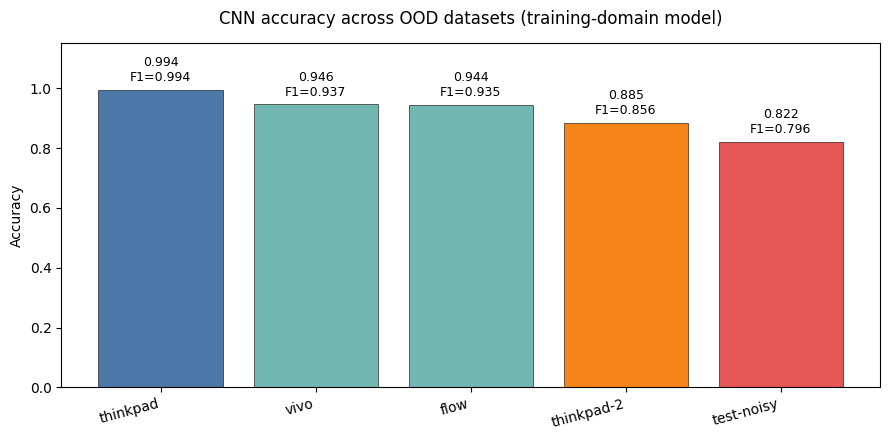

,summary_csv,bar_chart
0,cnn-cross-eval-results/summary.csv,cnn-cross-eval-results/accuracy_cross_dataset.png


### Per-class recall: thinkpad-2 − thinkpad (worst deltas)

,class,recall_thinkpad,recall_thinkpad2,delta
0,D_minor_4,1.000,0.000,-1.000
1,G#_diminished_4,1.000,0.000,-1.000
2,E_diminished_4,0.925,0.000,-0.925
3,A#_diminished_4,1.000,0.525,-0.475
4,C_diminished_4,1.000,0.700,-0.300
5,B_major_4,1.000,0.750,-0.250
6,D_diminished_4,1.000,0.950,-0.050
7,F_major_4,1.000,0.975,-0.025
8,F_minor_4,1.000,1.000,0.000
9,F_diminished_4,1.000,1.000,0.000


### Best deltas

,class,recall_thinkpad,recall_thinkpad2,delta
0,A_minor_4,1.000,1.000,0.0
1,A_major_4,1.000,1.000,0.0
2,A_diminished_4,1.000,1.000,0.0
3,A#_minor_4,1.000,1.000,0.0
4,A#_major_4,1.000,1.000,0.0
5,G_major_4,1.000,1.000,0.0
6,G_minor_4,1.000,1.000,0.0
7,C_major_4,0.875,0.975,0.1


In [5]:
import matplotlib.pyplot as plt

rows = []
for spec in EVAL_SETS:
    mpath = metrics_path(spec["name"])
    if path.isfile(mpath):
        rows.append(pd.read_csv(mpath).iloc[0].to_dict())

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values("accuracy", ascending=False).reset_index(drop=True)
summary_df.to_csv(SUMMARY_PATH, index=False)

# Deltas vs thinkpad-2
if (summary_df["name"] == "thinkpad_2").any():
    base = float(summary_df.loc[summary_df["name"] == "thinkpad_2", "accuracy"].iloc[0])
    summary_df["delta_acc_vs_thinkpad2"] = summary_df["accuracy"] - base
    base_f1 = float(summary_df.loc[summary_df["name"] == "thinkpad_2", "macro_f1"].iloc[0])
    summary_df["delta_macro_f1_vs_thinkpad2"] = summary_df["macro_f1"] - base_f1

display(Markdown("### Accuracy ranking (all datasets)"))
display(summary_df[[
    "name", "domain", "kind", "n_samples", "accuracy", "macro_f1", "weighted_f1",
    "delta_acc_vs_thinkpad2", "delta_macro_f1_vs_thinkpad2",
] if "delta_acc_vs_thinkpad2" in summary_df.columns else [
    "name", "domain", "kind", "n_samples", "accuracy", "macro_f1", "weighted_f1",
]])

# Highlight OOD only (exclude training for fair OOD bar)
ood = summary_df[summary_df["kind"] != "in_domain"].copy()
ood = ood.sort_values("accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = []
for n in ood["name"]:
    if n == "thinkpad_2":
        colors.append("#F58518")
    elif n == "thinkpad":
        colors.append("#4C78A8")
    elif n == "test_noisy":
        colors.append("#E45756")
    else:
        colors.append("#72B7B2")
x = np.arange(len(ood))
bars = ax.bar(x, ood["accuracy"], color=colors, edgecolor="black", linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(ood["domain"], rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("CNN accuracy across OOD datasets (training-domain model)", pad=14)
for i, (acc, f1) in enumerate(zip(ood["accuracy"], ood["macro_f1"])):
    ax.text(i, acc + 0.02, f"{acc:.3f}\nF1={f1:.3f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
bar_path = path.join(RESULTS_DIR, "accuracy_cross_dataset.png")
fig.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame([{"summary_csv": SUMMARY_PATH, "bar_chart": bar_path}]))

# Per-class recall for thinkpad-2 vs thinkpad
from sklearn.metrics import recall_score

def load_preds(name):
    c = np.load(cache_path(name), allow_pickle=True)
    return c["y_true"], c["y_pred"], c["class_names"].astype(str)

if path.isfile(cache_path("thinkpad_2")) and path.isfile(cache_path("thinkpad")):
    yt2, yp2, names = load_preds("thinkpad_2")
    yt1, yp1, _ = load_preds("thinkpad")
    r2 = recall_score(yt2, yp2, labels=np.arange(len(names)), average=None, zero_division=0)
    r1 = recall_score(yt1, yp1, labels=np.arange(len(names)), average=None, zero_division=0)
    # both datasets are 40/class (1440 samples) — recall is directly comparable
    per = pd.DataFrame({
        "class": names,
        "recall_thinkpad": r1,
        "recall_thinkpad2": r2,
        "delta": r2 - r1,
    }).sort_values("delta")
    display(Markdown("### Per-class recall: thinkpad-2 − thinkpad (worst deltas)"))
    display(per.head(12).reset_index(drop=True))
    display(Markdown("### Best deltas"))
    display(per.tail(8).reset_index(drop=True))
    per.to_csv(path.join(RESULTS_DIR, "perclass_thinkpad_vs_thinkpad2.csv"), index=False)